## Zomato Restaurant Data Analysis using Python

#### UNDERSTANDING THE DATA (Ch.4)
#### Step 1: Importing necessary Python libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Step 2: Loading Dataset and Creating the data frame.
*   Creating the data frame.
*   display all column names.
*   setting pandas display option to display all columns.
*   display random few lines of data.

In [2]:
df = pd.read_csv(r'dataset\zomato-data.csv')
print(df.columns)
pd.set_option('display.max_columns', None)
print(df.sample(5))

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')
                      name online_order book_table   rate  votes  \
22         Cafe Coffee Day           No         No  3.6/5   28.0   
3    Addhuri Udupi Bhojana           No         No  3.7/5   88.0   
72           Spicy Tandoor           No         No  4.1/5    0.0   
145           Anna Kuteera          Yes         No  4.0/5  771.0   
130   Roll Magic Fast Food           No         No  3.4/5    0.0   

     approx_cost(for two people) listed_in(type)  
22                         900.0           Cafes  
3                          300.0          Buffet  
72                         150.0          Dining  
145                        450.0          Dining  
130                        200.0          Dining  


#### Step 3: Getting summary of the dataframe 
*   Getting shape of data using df.shape()
*   Getting summary of the dataframe using df.info() 

In [3]:
print("Shape of dataset:",df.shape)
print("----------Dataset summary------------------")
df.info()

Shape of dataset: (148, 7)
----------Dataset summary------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    object 
 4   votes                        144 non-null    float64
 5   approx_cost(for two people)  145 non-null    float64
 6   listed_in(type)              148 non-null    object 
dtypes: float64(2), object(5)
memory usage: 8.2+ KB


This helps identify:
*	Number of rows and columns
*	Data types
*	Missing values


### UNDERSTANDING SPREAD OF DATA (Ch.5)
#### Visualize the spread of 'rate' using a Histogram
With our dataset we have used histogram with “kde=True” to understand the distribution and spread of data in column “rate” (user ratings). 

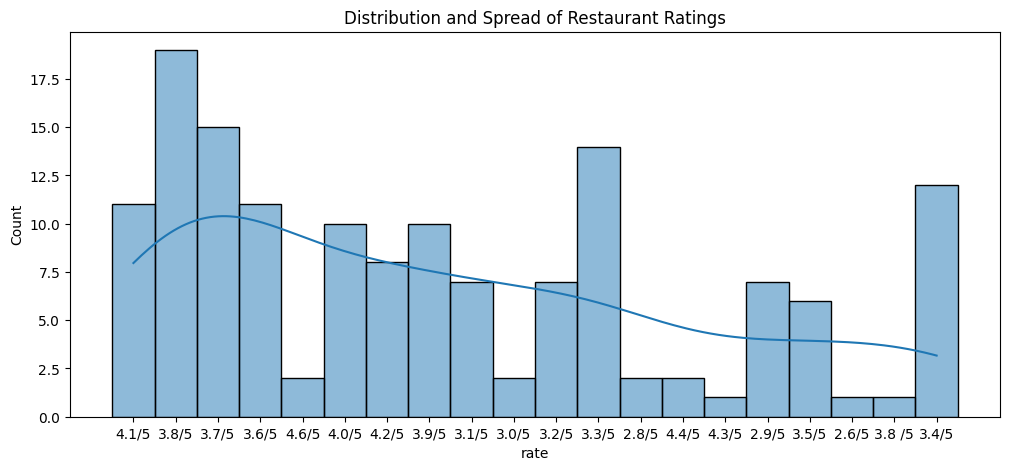

In [4]:
plt.figure(figsize=(12, 5))
sns.histplot(df['rate'], bins=10, kde=True)
plt.title("Distribution and Spread of Restaurant Ratings")
plt.show()

#### Convert the rate column to a float by removing denominator characters.

Data Cleaning and Preparation

df['rate']=df['rate'].apply(handleRate):
Applies the handleRate function to clean and convert each rating value in the
'rate' column.

In [5]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)

print("----------After cleaning rate column, printing top few records")
print(df[['name','rate']].head())

----------After cleaning rate column, printing top few records
                    name  rate
0                  Jalsa   4.1
1         Spice Elephant   4.1
2        San Churro Cafe   3.8
3  Addhuri Udupi Bhojana   3.7
4          Grand Village   3.8


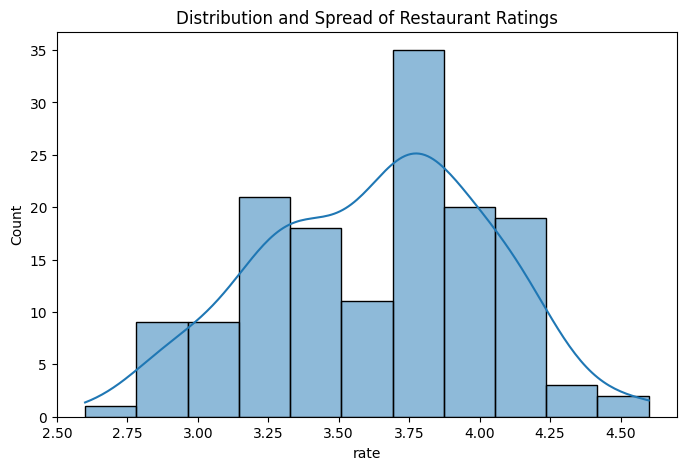

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['rate'], bins=11, kde=True)
plt.title("Distribution and Spread of Restaurant Ratings")
plt.show()

DONT USE THIS
Further we have used boxplot to understand the data spread of “approximate cost for two people” by online order availability.


#### 2. Compare the spread of 'approx_cost' across 'online_order' categories using Box Plots

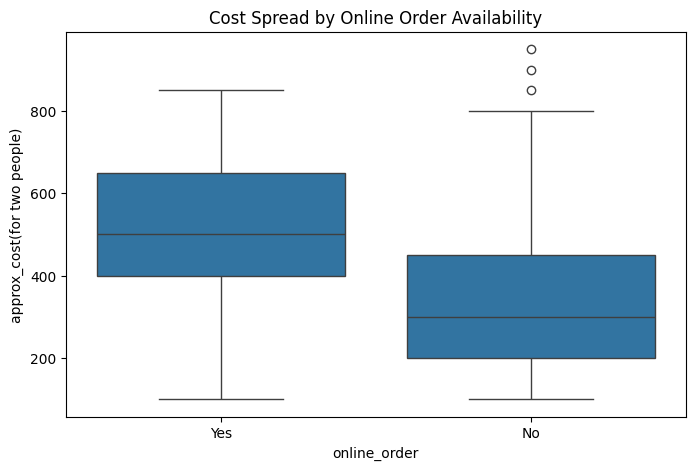

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='online_order', y='approx_cost(for two people)',
data=df)
plt.title("Cost Spread by Online Order Availability")
plt.show() 

### Automating EDA using python (Ch.6)
Creating a UDF which display all Information for EDA in single code  

In [8]:
def amroli_auto(data):
    print("Dataset Info:")
    print(data.info())
    print("\nDataset Description:")
    print(data.describe())
    print("\nMissing Values:")
    print(data.isnull().sum())

amroli_auto(df)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        144 non-null    float64
 5   approx_cost(for two people)  145 non-null    float64
 6   listed_in(type)              148 non-null    object 
dtypes: float64(3), object(4)
memory usage: 8.2+ KB
None

Dataset Description:
             rate        votes  approx_cost(for two people)
count  148.000000   144.000000                   145.000000
mean     3.633108   265.729167                   415.517241
std      0.402271   662.490314                   221.697777
min      2.600000     0.000000           

#### Auto EDA Reports using ydata-profiling library

In [9]:
#%pip install ydata-profiling

from ydata_profiling import ProfileReport
profile = ProfileReport(df, title="EDA Report")
profile.to_file("AutoReportUsing-ydataProfiling.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 466.70it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

#### Auto EDA Reports using sweetviz library

In [10]:
# pip install sweetviz
import sweetviz as sv
import pandas as pd

report = sv.analyze(df)
report.show_html('sweetviz_report.html')


                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### Auto EDA Reports using eda report library

In [14]:
# pip install eda-report
from eda_report.summarize import summarize

# Creates a Word document report
summarize('data.csv')


ModuleNotFoundError: No module named 'eda_report'

### Handling missing data and outliers (Data cleaning and preparation) (Ch.7)
#### Step 4: Data Cleaning and Preparation

In [11]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

df['rate']=df['rate'].apply(handleRate)
print("----------After cleaning rate column, printing top records")
print(df[['name','rate']].head()) 


----------After cleaning rate column, printing top records
                    name  rate
0                  Jalsa   4.1
1         Spice Elephant   4.1
2        San Churro Cafe   3.8
3  Addhuri Udupi Bhojana   3.7
4          Grand Village   3.8


#### Handling Outliers

As far as outliers are concerned, the outlier values are not incorrect data in this dataset and hence are meaningful for this analysis. 

#### Step 5: Checking for missing or null values to identify any data gaps (EDA)

In [12]:
# Step 5: Checking for missing or null values to identify any data gaps (EDA)
print("---------Checking for missing or null values")
print(df.isnull().sum())

---------Checking for missing or null values
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          4
approx_cost(for two people)    3
listed_in(type)                0
dtype: int64


#### Step 6: Handling missing data: filling gaps with mean value (Data Preparation)

There are a few missing values found in “votes” (number of votes for restaurant) and
“approx_cost (for two people)” columns. We have filled up missing values using mean values. 

In [13]:
df_cleaned = df.fillna(df.mean(numeric_only=True))
print("displaying null value count after handling missing data with mean value")
print(df_cleaned.isnull().sum())
dataframe = df_cleaned

displaying null value count after handling missing data with mean value
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


# Step 7: EDA - Univariate Analysis (Ch.8)
Exploring Restaurant Types (EDA - Univariate Analysis)

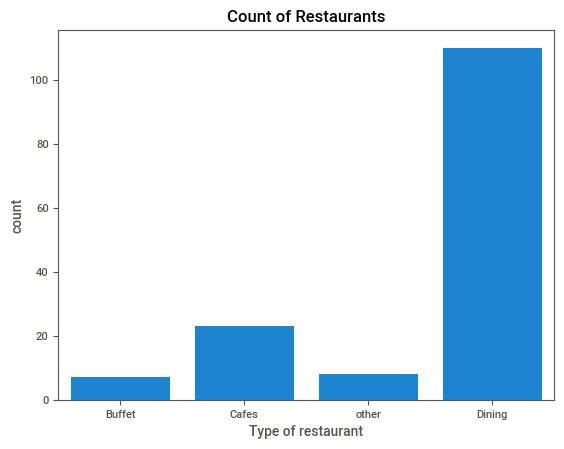

In [14]:
# Exploring Restaurant Types (EDA - Univariate Analysis)
sns.countplot(x=dataframe['listed_in(type)'])
plt.title("Count of Restaurants")
plt.xlabel("Type of restaurant")
plt.show()

* Conclusion: The majority of the restaurants fall into the dining category. 

##### Identify the Most Voted Restaurant (Univariate)

In [15]:
# Identify the Most Voted Restaurant
max_votes = dataframe['votes'].max()
restaurant_with_max_votes = dataframe.loc[dataframe['votes'] ==
max_votes, 'name']
print('Restaurant(s) with the maximum votes:')
print(restaurant_with_max_votes)

Restaurant(s) with the maximum votes:
38    Empire Restaurant
Name: name, dtype: object


* Conclusion: Empire State restaurant is most voted restaurant

#### Online Order Availability

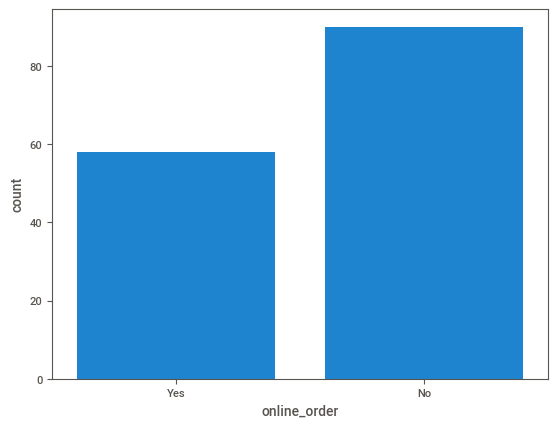

In [16]:
# Online Order Availability
sns.countplot(x=dataframe['online_order'])
plt.show()

* Conclusion: majority of the restaurants do not accept online orders.

#### Analyze customer ratings Ratings 


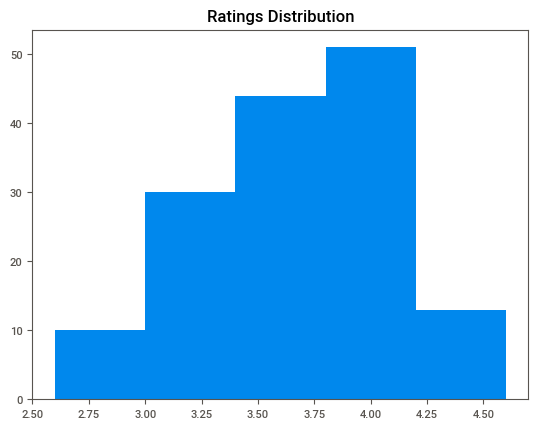

In [17]:
# Analyze customer ratings Ratings
plt.hist(dataframe['rate'],bins=5)
plt.title('Ratings Distribution')
plt.show()

* Conclusion: The majority of restaurants received ratings ranging from 3.5 to 4.

#### Approximate Cost of dining for Couples

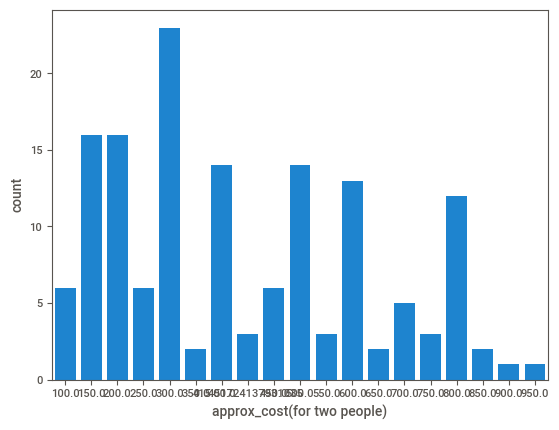

In [18]:
# Analysing approx_cost(for two people) column to find the preferred price range
couple_data=dataframe['approx_cost(for two people)']
sns.countplot(x=couple_data)
plt.show()

* Conclusion: The majority of couples prefer restaurants with an approximate cost of 300 rupees.

# Step 8: EDA - Bivariate Analysis(Ch.9)

#### Exploring Votes by Restaurant Type (EDA - Bivariate Analysis)

In [19]:
grouped_data = dataframe.groupby('listed_in(type)')['votes'].sum()
print(grouped_data)
result = pd.DataFrame({'votes': grouped_data})
print(result)

listed_in(type)
Buffet     3028.000000
Cafes      6415.458333
Dining    20495.729167
other      9388.729167
Name: votes, dtype: float64
                        votes
listed_in(type)              
Buffet            3028.000000
Cafes             6415.458333
Dining           20495.729167
other             9388.729167


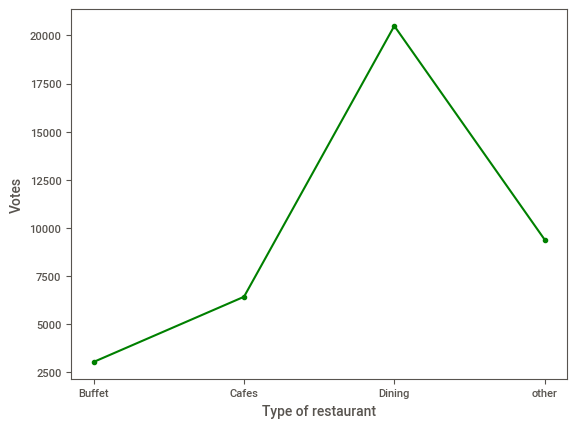

In [20]:
plt.plot(result, c='green', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')
plt.show()

* Conclusion: Dining restaurants are preferred by a larger number of individuals

#### Ratings Comparison - Online vs Offline Orders

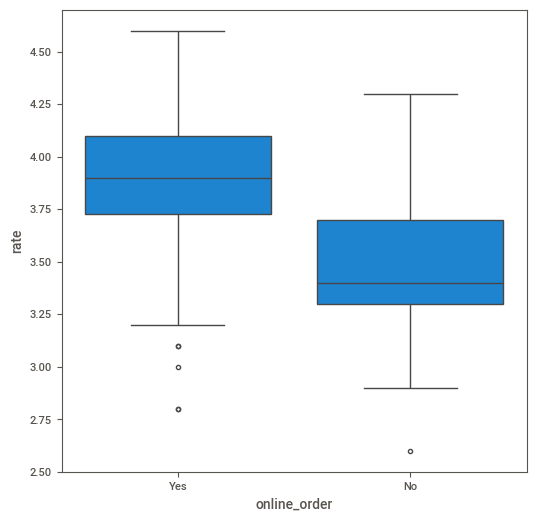

In [21]:
# Ratings Comparison - Online vs Offline Orders
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = dataframe)
plt.show()

* Conclusion: Offline orders received lower ratings in comparison to online  orders which obtained excellent ratings. 

# Step 9: EDA - Multivariate Analysis (Ch.10)
#### Order Mode Preferences by Restaurant Type

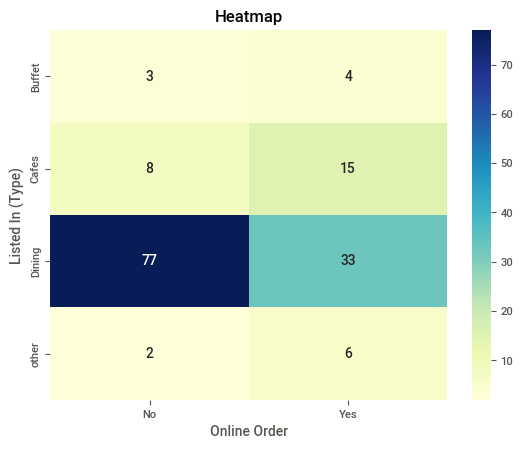

In [22]:
# Order Mode Preferences by Restaurant Type
pivot_table = dataframe.pivot_table(index='listed_in(type)',
columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

* Conclusion: With this we can say that dining restaurants primarily receive  offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at dining restaurants but prefer online ordering at cafes.

#### Regression Model Supervised Learning (Ch.11)

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df['online_order'] = df['online_order'].map({'Yes':1,'No':0})
X = df[['votes','approx_cost(for two people)','online_order']]
y = df['rate']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)


##### Model Evaluation (Ch.12)

In [ ]:
print("MSE:",mean_squared_error(y_test,pred))
print("MAE:",mean_absolute_error(y_test,pred))
print("R2:",r2_score(y_test,pred))


#### Classification Model (Ch.13)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

df['rating_class'] = df['rate'].apply(lambda x: 1 if x>=4 else 0)
X = df[['votes','approx_cost(for two people)','online_order']]
y = df['rating_class']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
clf = LogisticRegression()
clf.fit(X_train,y_train)
pred = clf.predict(X_test)

#### Model Evaluation

In [ ]:
print("Accuracy:",accuracy_score(y_test,pred))
print(confusion_matrix(y_test,pred))

#### Overfitting and underfitting (ch.14)

Determine that model is Overfitting or Underfitting based on results
•	If training accuracy is high and testing accuracy is low → Overfitting
•	If both accuracies are low → Underfitting
This model shows acceptable generalization with moderate accuracy.


##### More Information for Referencing 

Understanding the Metrics
MAE (Mean Absolute Error)
MAE = average(|actual - predicted|)
•	Measures average prediction error.
•	Lower MAE = better model.

Example:
MAE = 0.25
means predictions differ by 0.25 on average.


MSE (Mean Squared Error)

MSE = average((actual - predicted)^2)
•	Penalizes larger errors more.
•	Lower value = better model.


R² Score (Coefficient of Determination)

R² = 1 - (SS_residual / SS_total)

Interpretation:
R² Score	Meaning
1	Perfect model
0.8+	Good
0.5	Moderate
<0	Poor model


Sample Example Output (Typical)
MAE : 0.29
MSE : 0.14
R2 Score : 0.38

Interpretation:
•	MAE 0.29 → predictions off by ~29%
•	MSE 0.14 → moderate error
•	R² 0.38 → model explains 38% variance


Improving the Model (Realistic Improvements)
You could improve results by:
1️⃣ Feature engineering
2️⃣ Scaling
3️⃣ Better models
Example:
•	Random Forest
•	Gradient Boosting
•	Logistic Regression (best for Titanic)


#### Conclusion (Ch.15)

This project successfully demonstrates how data analytics and machine learning techniques can be applied to restaurant business data. Through EDA, regression, and classification, meaningful insights were extracted, and predictive models were built to understand customer behaviour.

Write you project conclusion here, 
what you derived from EDA and ML Model.